In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor


In [24]:
df = pd.read_csv("Housing.csv")

In [ ]:
df = pd.get_dummies(df, drop_first=True)

X = df.drop("price", axis=1)
y = df["price"]

In [26]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [27]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor()
}

In [ ]:
rmseResults = []
mseResults = []

for name, model in models.items():
    scores = cross_val_score(
        model, X, y,
        cv=kf,
        scoring="neg_mean_squared_error"
    )
    
    mse = -np.mean(scores)
    rmse = np.sqrt(mse)
    print(f'{name}')
    print(f"\tAverage MSE: {mse}")
    print(f'\tRoot MSE: {rmse}')
    rmseResults.append(rmse)
    mseResults.append(mse)
    print()

Linear Regression
	Average MSE: 1196890161786.7837
	Root MSE: 1094024.7537358485

Decision Tree
	Average MSE: 2665065582102.3853
	Root MSE: 1632502.858221812

Random Forest
	Average MSE: 1262908034706.233
	Root MSE: 1123791.8111048117



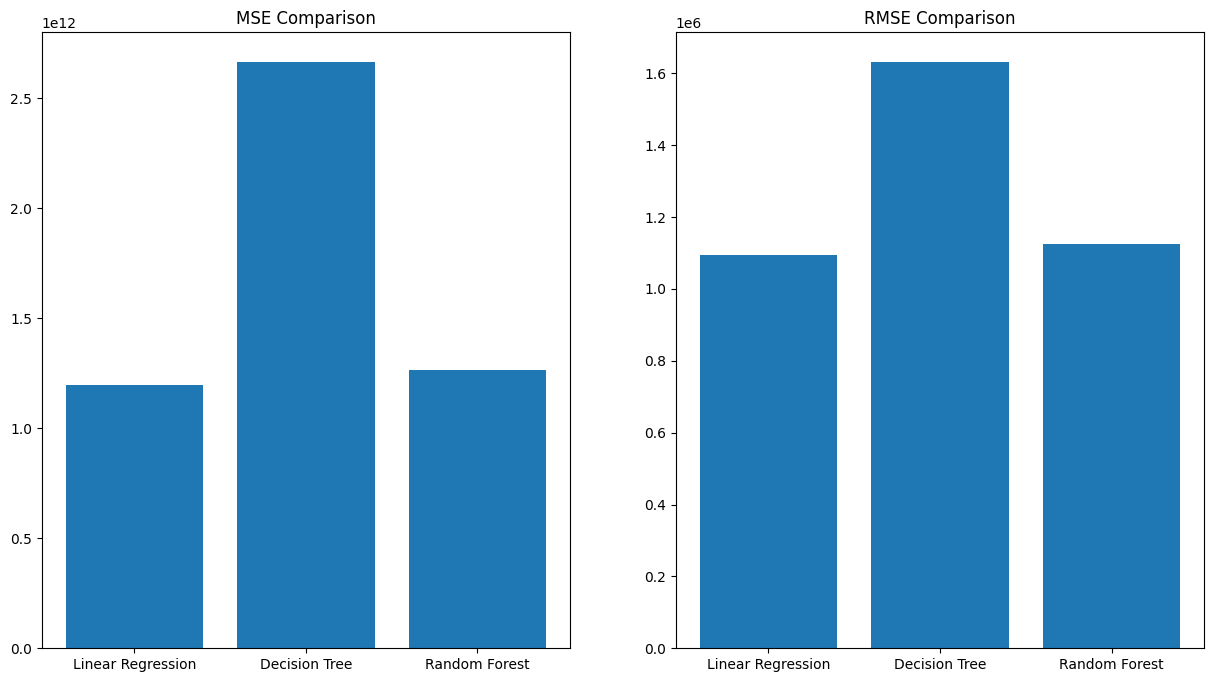

In [45]:
import matplotlib.pyplot as plt

modelNames = ['Linear Regression', 'Decision Tree', 'Random Forest']

plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.bar(modelNames, mseResults)
plt.title("MSE Comparison")
# plt.xticks(rotation=20)

plt.subplot(1, 2, 2)
plt.bar(modelNames, rmseResults)
plt.title("RMSE Comparison")
# plt.xticks(rotation=20)
plt.show()